# Actor-Critic Learning in Gridworld

This notebook demonstrates the Actor-Critic reinforcement learning algorithm in a simple 4x4 Gridworld environment. The agent learns to navigate the grid to maximize its cumulative reward using both value-based (critic) and policy-based (actor) updates. The notebook covers environment setup, reward structure, state transitions, return and TD update functions, agent training, and visualization of learned policies and value functions.

### Import Required Libraries
These libraries are used for numerical operations, randomization, plotting, and implementing the softmax function for policy calculation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

### Initialize Environment and Parameters
Set up the reward structure for the grid, define terminal and penalty states, initialize state values, action log-probabilities, learning rate, and a log for tracking scores.

In [ ]:
rewards = np.zeros(16)
rewards[3] = 10
rewards[2] = -1
rewards[11] = -1
rewards[10] = -1

terminal_state = 3
state_values = np.zeros(16)
state_action_logprobs = np.random.random((16,4))
alpha = 0.002 # default: 0.005

score_log = []

### Visualize Reward Structure
Display the reward matrix for the 4x4 grid to show locations of rewards and penalties.

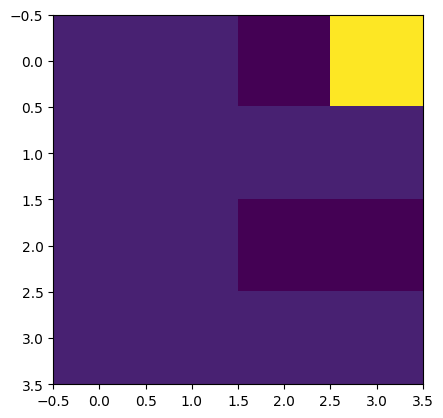

In [3]:
plt.imshow(rewards.reshape(4, 4))

### Load State Transition Table
Load the state transition table from a CSV file, which defines how the agent moves in the grid given its current state and action.

In [4]:
state_transition_table = np.genfromtxt("state_transitions.csv", delimiter=",").astype(int)

### Define Returns Calculation Function
This function computes the discounted returns for a sequence of rewards, which is used for policy and value updates.

In [5]:
def returns_calc(rewards):
    returns = []
    R = 0
    gamma = 0.9
    for i in reversed(range(len(rewards))):
        R = rewards[i] + gamma * R
        returns.insert(0, R)
    return returns

### Define Temporal Difference (TD) Update Function
This function performs the TD update for the value function (critic), adjusting state values based on observed rewards and estimated future values.

In [6]:
def TD_update(next_val, values, rewards, states):
    gamma = 0.9
    next_val = next_val
    #fixed bug in code here
    new_values = np.zeros(16) + values
    for i in reversed(range(len(rewards))):
        new_values[states[i]] = values[states[i]] + alpha * (rewards[i] + gamma * next_val - values[states[i]])
        next_val = values[states[i]]
    return new_values

### Define Agent Testing Function
This function runs the agent in the environment using the current policy to evaluate its performance and returns the total reward and the sequence of visited states.

In [7]:
def test_agent():
    state = 12
    steps = 0
    total_rewards = 0
    states_log = []
    while (not(state == terminal_state)) and steps<30:
        states_log.append(state)
        action = np.argmax(np.random.multinomial(1, softmax(state_action_logprobs[state]), size=1))
        state = state_transition_table[state, action]
        total_rewards += rewards[state]
        steps += 1
    states_log.append(state)
    return total_rewards, states_log

### Train the Agent with Actor-Critic Updates
This loop runs multiple episodes where the agent interacts with the environment, collects rewards, updates the value function (critic) and policy (actor), and logs the performance.

In [8]:
for _ in range(2000):
    state = 12
    state_log = []
    reward_log = []
    action_log = []
    values_log = []

    steps = 0

    while (not(state == terminal_state)) and steps<30:
        action = np.argmax(np.random.multinomial(1, softmax(state_action_logprobs[state]), size=1))
        
        state_log.append(state)
        values_log.append(state_values[state])
        action_log.append(action)

        state = state_transition_table[state, action]
        reward_log.append(rewards[state])

        steps += 1
        
    next_val = state_values[state]
    
    state_values = TD_update(next_val, state_values, reward_log, state_log)
    state_returns = returns_calc(reward_log)
    advantage = np.subtract(state_returns, values_log)
    
    state_action_logprobs[state_log, action_log] = state_action_logprobs[state_log, action_log] + \
                                                alpha*advantage
    
    score_log.append(test_agent()[0])

### Visualize Learned Policy
Display the learned policy as a matrix, showing the probability of each action in each state after training.

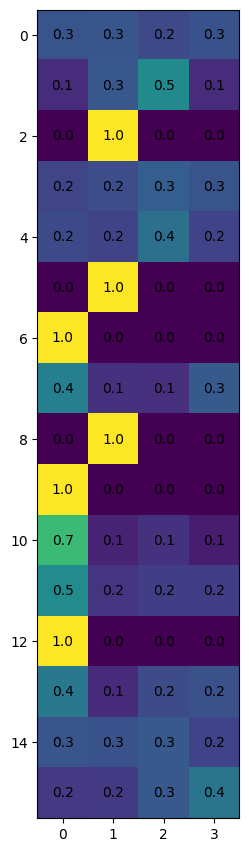

In [9]:
fig, ax1 = plt.subplots(1)
fig.set_size_inches(18.5, 10.5)
ax1.imshow(softmax(state_action_logprobs, 1).reshape(16, 4))

for (j,i), label in np.ndenumerate(softmax(state_action_logprobs, 1).reshape(16, 4).round(1)):
    ax1.text(i,j,label,ha='center',va='center')

### Visualize Learned Value Function
Show the state value estimates as a heatmap to illustrate which states are considered more valuable after training.

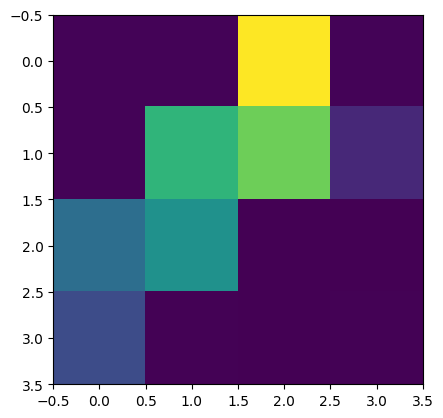

In [10]:
plt.imshow(state_values.reshape(4, 4))

### Plot Training Progress
Plot the total reward obtained by the agent over episodes to visualize learning progress.

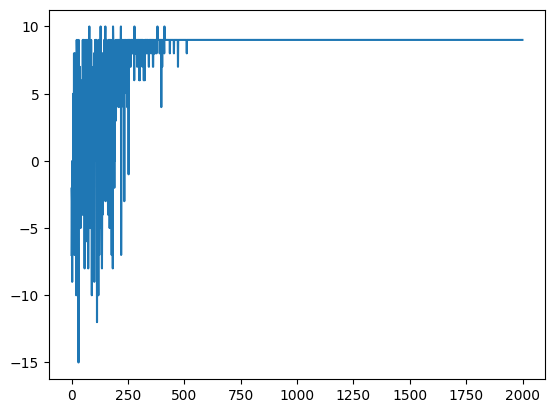

In [11]:
plt.plot(score_log)

### Visualize Agent's Path
Show the path taken by the agent in the grid using the learned policy, highlighting the visited states.

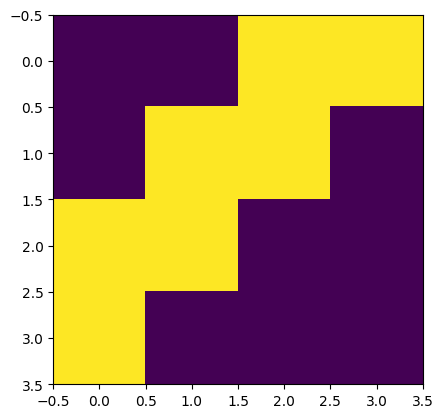

In [12]:
_, state_log = test_agent()
state_view = np.zeros(16)
state_view[state_log] = 1
plt.imshow(state_view.reshape(4,4))